In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

In [3]:
DATA_PATH = Path("../data/processed/crop_recommendation_clean.csv")

df = pd.read_csv(DATA_PATH)

df.head()

,n,p,k,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [4]:
target_col = "label"

X = df.drop(columns=[target_col])
y = df[target_col]

X.head()

,n,p,k,temperature,humidity,ph,rainfall
0,90,42,43,20.879744,82.002744,6.502985,202.935536
1,85,58,41,21.770462,80.319644,7.038096,226.655537
2,60,55,44,23.004459,82.320763,7.840207,263.964248
3,74,35,40,26.491096,80.158363,6.980401,242.864034
4,78,42,42,20.130175,81.604873,7.628473,262.717340


In [5]:
X.columns.tolist()

['n', 'p', 'k', 'temperature', 'humidity', 'ph', 'rainfall']

## Exploratory Data Analysis

Exploratory data analysis was performed to understand the structure, distribution, and separability of the crop recommendation dataset.

Key findings:

- The dataset is perfectly balanced across 22 crop classes.
- All input features are numeric.
- There are no missing values or duplicate records.
- Feature ranges differ considerably, making scaling important for some machine learning models.
- Crop-wise feature summaries show that different crops occupy distinct soil and climate profiles.
- PCA visualization shows partial class separation, suggesting that the full feature space is useful for crop classification.

Generated EDA visuals include:

- Crop class distribution chart
- Feature distribution plots
- Crop-wise boxplots
- Correlation heatmap
- Crop feature profile heatmap
- PCA class-separation plot

In [6]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

Stratified K-Fold cross-validation preserves the crop class distribution in each fold. This ensures that each training and validation split contains a representative sample of all crop classes.

In [7]:
feature_scores = {}

for feature in X.columns:
    pipeline = Pipeline(
        steps=[
            ("scaler", StandardScaler()),
            ("model", LogisticRegression(max_iter=5000))
        ]
    )

    scores = cross_val_score(
        pipeline,
        X[[feature]],
        y,
        cv=cv,
        scoring="f1_macro"
    )
    feature_scores[feature] = scores.mean()

feature_scores

{'n': np.float64(0.10742014850968003),
 'p': np.float64(0.15098133596853608),
 'k': np.float64(0.19105028944772762),
 'temperature': np.float64(0.13400428745212534),
 'humidity': np.float64(0.2574257116187257),
 'ph': np.float64(0.08096506486413539),
 'rainfall': np.float64(0.2582112044881209)}

In [8]:
feature_score_df = (
    pd.DataFrame({
        "feature": feature_scores.keys(),
        "macro_f1": feature_scores.values()
    })
    .sort_values("macro_f1", ascending=False)
    .reset_index(drop=True)
)

feature_score_df

,feature,macro_f1
0,rainfall,0.258211
1,humidity,0.257426
2,k,0.191050
3,p,0.150981
4,temperature,0.134004
5,n,0.107420
6,ph,0.080965


In [10]:
best_feature = feature_score_df.loc[0, "feature"]
best_score = feature_score_df.loc[0, "macro_f1"]

best_predictive_feature = {
    best_feature: round(best_score, 4)
}

best_predictive_feature

{'rainfall': np.float64(0.2582)}

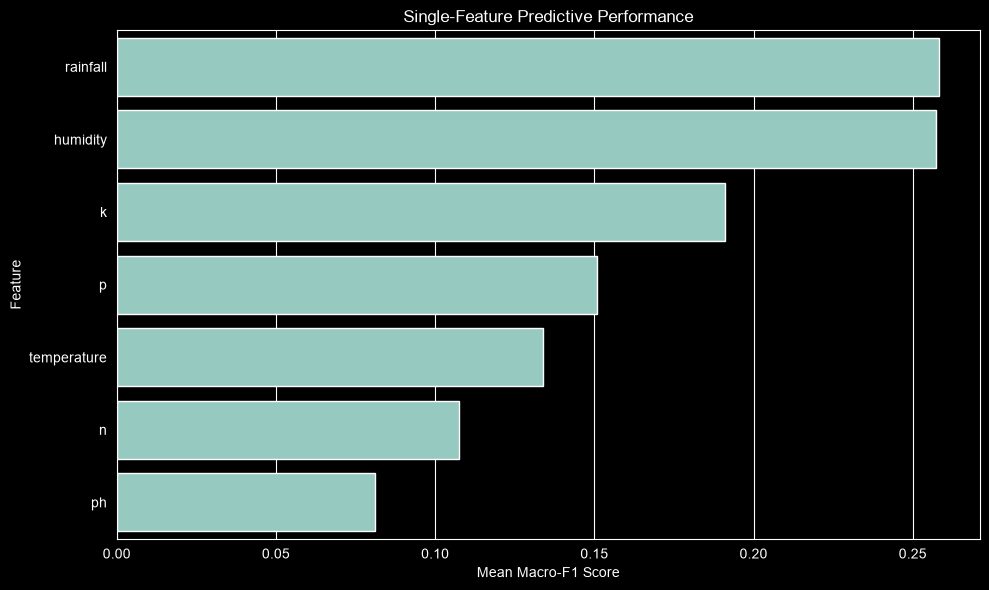

In [13]:
plt.figure(figsize=(10, 6))
sns.barplot(
    data=feature_score_df,
    x="macro_f1",
    y="feature"
)
plt.title("Single-Feature Predictive Performance")
plt.xlabel("Mean Macro-F1 Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

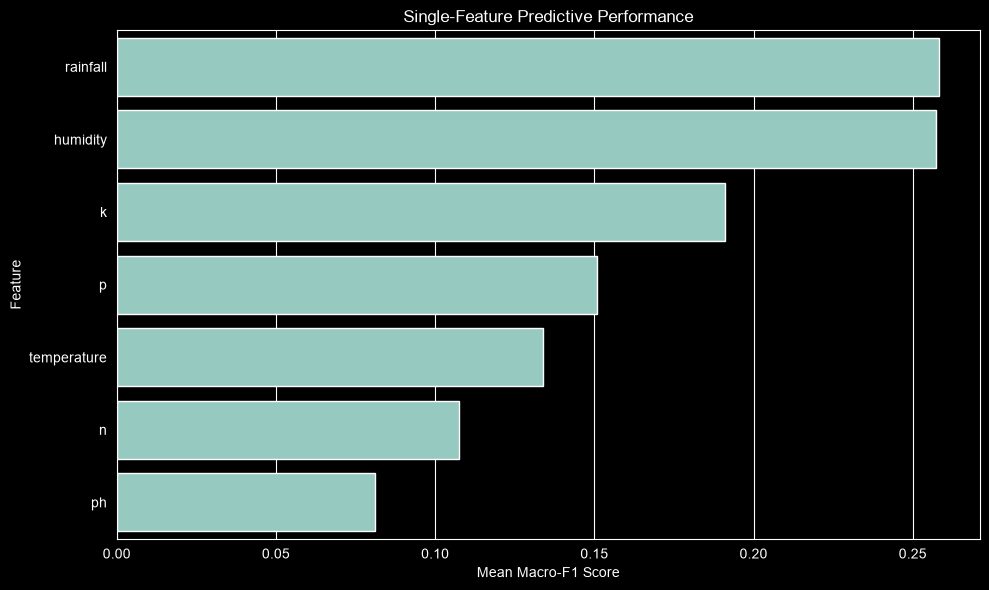

In [12]:
plt.figure(figsize=(10, 6))
sns.barplot(
    data=feature_score_df,
    x="macro_f1",
    y="feature"
)
plt.title("Single-Feature Predictive Performance")
plt.xlabel("Mean Macro-F1 Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig("../reports/figures/single_feature_performance.png", dpi=300)
plt.show()

## Single-Feature Baseline Interpretation

Rainfall produced the best single-feature macro-F1 score among all predictors. This suggests that rainfall alone contains the strongest individual signal for distinguishing crop classes in this dataset.

However, the best single-feature score is still low compared with what is expected from a full multi-feature model. This means that no single variable is sufficient for reliable crop recommendation. Crop suitability depends on a combination of soil nutrients, pH, rainfall, humidity, and temperature.

The single-feature baseline is useful because it gives a simple reference point before building more powerful models using the full feature set.